# Chapter 44: Loss Functions for CV

**Does focal loss beat cross-entropy on the metric that is scored, and what does it cost elsewhere?**

Focal loss is a popular answer to class imbalance, and the chapter asks that it win against an unchanged cross-entropy reference on the scored metric before it is kept. Sixteen paired trainings show where the gain stops and what changes silently, such as the scale of the predicted probabilities.

*Constructed data with a hard minority subgroup; the sizes of these effects are properties of this generator, not a competition result.*

## The experiment

A constructed binary task with 5% positives, six numeric features and a hard subgroup (30% of positives look like negatives on the first feature). A one-hidden-layer network, 16 tanh units, is trained full-batch with Adam on the focal loss with the control's gamma and, from the same start and the same rows, on cross-entropy (gamma = 0). The 2,000 training rows hold about 100 positives. Both models are scored on 12,000 fresh rows by average precision (the ranking metric), by F1 at the default cutoff of 0.5, by F1 at a cutoff tuned on a separate 2,000 development rows, by log loss and by the mean predicted probability, averaged over 16 draws.

In [1]:
import numpy as np
from sklearn.metrics import average_precision_score, log_loss

from kaggle_companion.activities._common import clean

SEED = 44
DRAWS = 16        # independent training sets; every estimate is a mean over draws
N_TRAIN, N_DEV, N_ASSESS = 2000, 2000, 12000
PREVALENCE = 0.05


def generate(n, rng):
    """Rare positives (5%). Two features separate them, and 30% of positives form a hard subgroup that looks different."""
    y = (rng.random(n) < PREVALENCE).astype(int)
    X = rng.normal(size=(n, 6))
    X[:, 0] += 1.4 * y
    X[:, 1] += 0.9 * y
    hard = (y == 1) & (rng.random(n) < 0.3)
    X[hard, 0] -= 1.4          # the hard positives hide on feature 0 ...
    X[hard, 2] += 2.0          # ... and show up on feature 2 instead
    return X, y


def focal_loss(z, y, gamma):
    """Mean binary focal loss on logits z: -(1 - p_t)^gamma * log(p_t). gamma = 0 is ordinary cross-entropy."""
    p = np.clip(1 / (1 + np.exp(-z)), 1e-7, 1 - 1e-7)
    p_t = np.where(y == 1, p, 1 - p)
    return float(np.mean(-((1 - p_t) ** gamma) * np.log(p_t)))


def focal_grad(z, y, gamma):
    """Derivative of the focal loss with respect to each logit (checked against finite differences in verify)."""
    p = np.clip(1 / (1 + np.exp(-z)), 1e-7, 1 - 1e-7)
    q = 1 - p
    pos = gamma * p * q ** gamma * np.log(p) - q ** (gamma + 1)
    neg = -(gamma * q * p ** gamma * np.log(q) - p ** (gamma + 1))
    return np.where(y == 1, pos, neg)


def fit_mlp(X, y, gamma, seed, hidden=16, epochs=200, lr=0.03, decay=1e-3):
    """One-hidden-layer network trained full-batch with Adam on the focal loss. Returns a predict-probability function."""
    rng = np.random.default_rng(seed)
    n, d = X.shape
    params = [rng.normal(0, 1 / np.sqrt(d), (d, hidden)), np.zeros(hidden), rng.normal(0, 1 / np.sqrt(hidden), hidden), np.array([-2.0])]
    m1 = [np.zeros_like(p) for p in params]
    m2 = [np.zeros_like(p) for p in params]
    for t in range(1, epochs + 1):
        h = np.tanh(X @ params[0] + params[1])
        dz = focal_grad(h @ params[2] + params[3][0], y, gamma) / n
        dh = np.outer(dz, params[2]) * (1 - h ** 2)
        grads = [X.T @ dh + decay * params[0], dh.sum(0), h.T @ dz + decay * params[2], np.array([dz.sum()])]
        for i, g in enumerate(grads):                       # Adam update
            m1[i] = 0.9 * m1[i] + 0.1 * g
            m2[i] = 0.999 * m2[i] + 0.001 * g * g
            params[i] -= lr * (m1[i] / (1 - 0.9 ** t)) / (np.sqrt(m2[i] / (1 - 0.999 ** t)) + 1e-8)

    def logit(X_new):
        return np.tanh(X_new @ params[0] + params[1]) @ params[2] + params[3][0]
    return logit


def f1(y, flagged):
    """F1 of the positive class: 2TP / (2TP + FP + FN)."""
    tp = np.sum(flagged & (y == 1))
    return 2 * tp / max(2 * tp + np.sum(flagged & (y == 0)) + np.sum(~flagged & (y == 1)), 1)


def tuned_threshold(y, p):
    """The probability cutoff that maximises F1 on development rows."""
    cuts = np.linspace(0.02, 0.9, 60)
    return cuts[np.argmax([f1(y, p >= c) for c in cuts])]


def score(logit, X_dev, y_dev, X_a, y_a):
    z = logit(X_a)
    p = np.clip(1 / (1 + np.exp(-z)), 1e-6, 1 - 1e-6)
    cut = tuned_threshold(y_dev, 1 / (1 + np.exp(-logit(X_dev))))
    return {"ap": average_precision_score(y_a, p), "f1_default": f1(y_a, p >= 0.5), "f1_tuned": f1(y_a, p >= cut),
            "log_loss": log_loss(y_a, p), "mean_probability": p.mean(), "flagged_default": (p >= 0.5).mean()}


def run(gamma):
    rng = np.random.default_rng(SEED)
    X_a, y_a = generate(N_ASSESS, rng)                         # assessment rows, used only for scoring
    rows = {"ce": [], "focal": []}
    for draw in range(DRAWS):
        X, y = generate(N_TRAIN, rng)
        X_d, y_d = generate(N_DEV, rng)
        for name, g in (("ce", 0.0), ("focal", float(gamma))):
            if name == "focal" and gamma == 0:             # gamma 0 is the comparator itself
                rows["focal"].append(rows["ce"][-1])
                continue
            rows[name].append(score(fit_mlp(X, y, g, seed=draw), X_d, y_d, X_a, y_a))
    keys = list(rows["ce"][0])
    mean = {name: {k: float(np.mean([r[k] for r in rs])) for k in keys} for name, rs in rows.items()}
    paired = {k: np.array([f[k] - c[k] for f, c in zip(rows["focal"], rows["ce"])]) for k in keys}
    # Sanity test from the chapter: gamma = 0 must reduce to ordinary cross-entropy.
    z_test = np.random.default_rng(0).normal(size=500)
    y_test = (np.random.default_rng(1).random(500) < 0.3).astype(int)
    p_test = 1 / (1 + np.exp(-z_test))
    return clean({
        "gamma": gamma,
        "ce": mean["ce"], "focal": mean["focal"],
        "ap_gain": paired["ap"].mean(), "ap_gain_se": paired["ap"].std(ddof=1) / np.sqrt(DRAWS) if gamma else 0.0,
        "ap_win_rate": float((paired["ap"] > 0).mean()) if gamma else 0.0,
        "f1_tuned_gain": paired["f1_tuned"].mean(), "f1_default_gain": paired["f1_default"].mean(),
        "gamma0_vs_log_loss": abs(focal_loss(z_test, y_test, 0.0) - log_loss(y_test, p_test)),
        "prevalence": PREVALENCE, "draws": DRAWS, "assessment_rows": N_ASSESS,
    })


## Measure it across the control

The control is **focusing parameter gamma (0 is ordinary cross-entropy)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch44 import explain

VALUES = [0, 1, 2, 5]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                               0               1               2               5
Average precision, cross-entropy           0.301           0.301           0.301           0.301
Average precision, focal                   0.301           0.309           0.322           0.291
Paired gain (standard error)      +0.000 (0.000)  +0.008 (0.002)  +0.021 (0.003)  -0.010 (0.004)
F1 at cutoff 0.5, focal                    0.218           0.224           0.198           0.080
Log loss, cross-entropy                    0.155           0.155           0.155           0.155
Log loss, focal                            0.155           0.187           0.256           0.426


## Look at it

The figure shows the default setting, focusing parameter gamma (0 is ordinary cross-entropy) = 2.

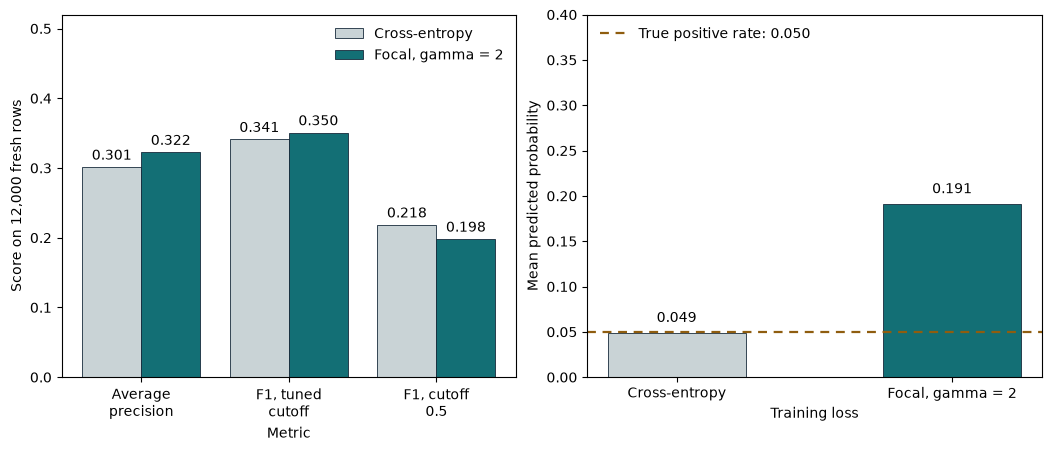

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch44 import draw, NCOLS, HEIGHT

DEFAULT = 2
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

At gamma 2, average precision is 0.322 against 0.301 for cross-entropy: 0.322 - 0.301 = 0.021 (standard error 0.003, better in 94% of the draws). The ranking improves. At the default cutoff F1 moves from 0.218 to 0.198; with a cutoff tuned on development rows it moves from 0.341 to 0.350. Log loss goes from 0.155 to 0.256 because the mean predicted probability is 0.191 on a 0.050 positive rate.

- Average precision: 0.322 - 0.301 = +0.021 (focal minus cross-entropy).
- F1 at the default cutoff: 0.198 - 0.218 = -0.020.
- F1 at the tuned cutoff: 0.350 - 0.341 = +0.009.
- Log loss: 0.256 - 0.155 = +0.101.

## Apply this to your competition

- Train the plain cross-entropy (or BCE) reference first and keep it in every comparison, under the same seeds and budget.
- Check the implementation at gamma = 0: it must reproduce ordinary cross-entropy before any focal run is trusted.
- Compare gamma values on the scored metric, averaged over seeds, and give each loss its own cutoff chosen on development rows.
- If probabilities are scored or blended, check their quality after a focal run and fit a calibrator on separate development rows when it is poor.

Book location: Chapter 44, Focal Loss for Imbalanced Classes.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)